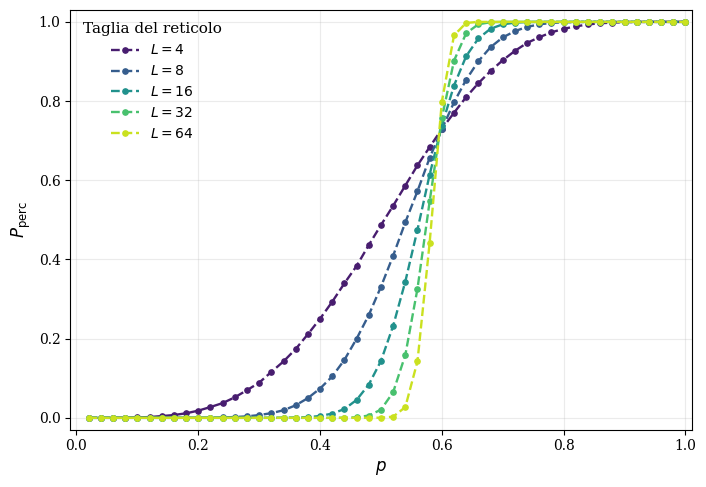

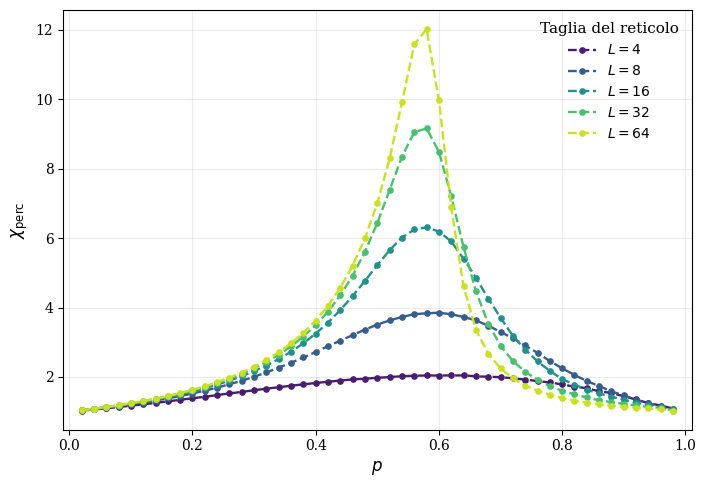

In [1]:
from __future__ import annotations

import argparse
import re
import warnings
from pathlib import Path
from glob import glob

import matplotlib.pyplot as plt
import numpy as np


def lattice_size(path: Path) -> tuple[float, str]:
    """Restituisce una chiave numerica e l'etichetta L ricavate dal nome."""
    match = re.search(r"Pperc_L([0-9]+(?:\.[0-9]+)?)", path)
    if match is None:
        raise ValueError(
            f"Impossibile ricavare L dal nome {path.name!r}; "
            "formato atteso: Pperc_L<numero>.dat"
        )
    label = match.group(1)
    return float(label), label


def load_data(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Legge le prime tre colonne, ignorando commenti e righe non numeriche."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        data = np.genfromtxt(
            path,
            comments="#",
            usecols=(0, 1, 2),
            invalid_raise=False,
            ndmin=2,
            encoding="utf-8",
        )

    valid = np.all(np.isfinite(data), axis=1)
    data = data[valid]
    if data.size == 0:
        raise ValueError(f"Nessuna riga numerica valida in {path}")

    # Ordinare per p evita segmenti incrociati se le righe non sono già ordinate.
    data = data[np.argsort(data[:, 0])]
    return data[:, 0], data[:, 1], data[:, 2]


def style_axis(ax: plt.Axes, ylabel: str) -> None:
    ax.set_xlabel(r"$p$")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="Taglia del reticolo", frameon=False)
    ax.margins(x=0.02)


def plot_p_chi():
    plt.rcParams.update({
        "font.family": "serif",       
        "font.size": 11,              
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
        "text.usetex": False          
    })
    
    files = list(glob("../../../CODICI/PERCOLATION/Pperc_L*.dat"))
    if not files:
        raise SystemExit(f"Nessun file trovato")

    try:
        files.sort(key=lambda path: lattice_size(path)[0])
    except ValueError as exc:
        raise SystemExit(str(exc)) from exc

    fig_p, ax_p = plt.subplots(figsize=(7.2, 5.0))
    fig_chi, ax_chi = plt.subplots(figsize=(7.2, 5.0))
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(files)))

    for path, color in zip(files, colors):
        _, label = lattice_size(path)
        try:
            p, p_perc, chi_perc = load_data(path)
        except (OSError, ValueError) as exc:
            raise SystemExit(f"Errore durante la lettura: {exc}") from exc

        # markevery mantiene leggibili anche curve con molti punti.
        markevery = 1
        common = dict(
            color=color,
            linewidth=1.7,
            linestyle="--",
            marker="o",
            markersize=3.8,
            markevery=markevery,
            label=fr"$L={label}$",
        )
        ax_p.plot(p, p_perc, **common)
        ax_chi.plot(p[:-1], chi_perc[:-1], **common)

    style_axis(ax_p, r"$P_{\mathrm{perc}}$")
    style_axis(ax_chi, r"$\chi_{\mathrm{perc}}$")
    ax_chi.set_xlim(-0.01, 1.01)
    ax_p.set_xlim(-0.01, 1.01)
    ax_p.set_ylim(-0.03, 1.03)

    fig_p.tight_layout()
    fig_chi.tight_layout()

    return fig_p, fig_chi


fig_p, fig_chi = plot_p_chi()


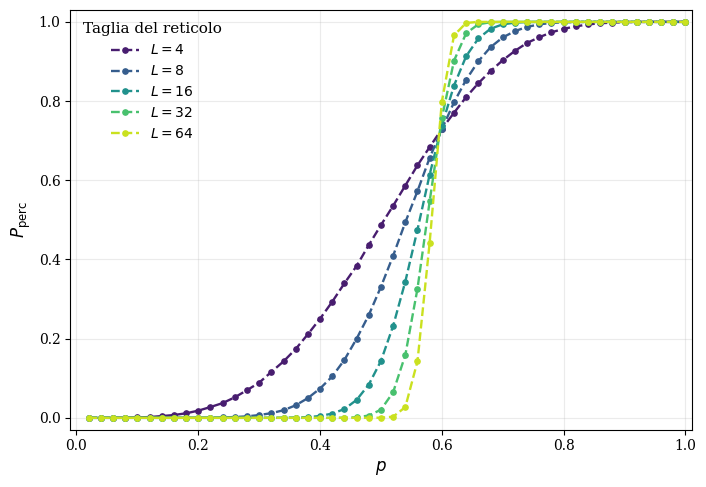

In [2]:
#| label: cell:P_perc
fig_p

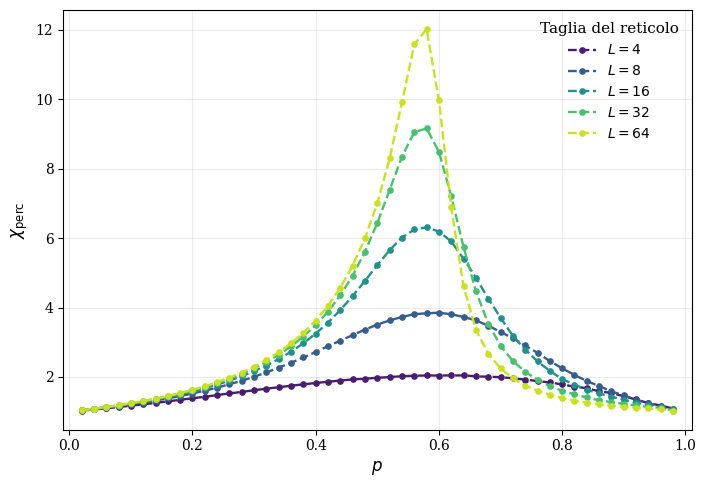

In [3]:
#| label: cell:chi_perc
fig_chi

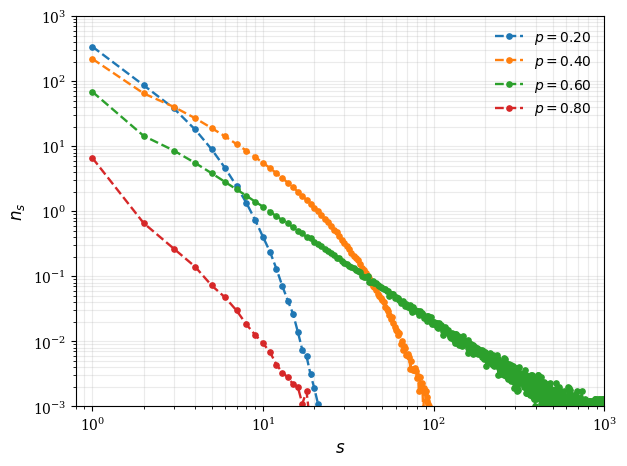

In [15]:
def p_occ(path: Path) -> tuple[float, str]:
    """Restituisce una chiave numerica e l'etichetta p ricavate dal nome."""
    match = re.search(r"csd_p([0-9]+(?:\.[0-9]+)?)", path)
    if match is None:
        raise ValueError(
            f"Impossibile ricavare p dal nome {path.name!r}; "
            "formato atteso: csd_p<numero>.dat"
        )
    label = match.group(1)
    return float(label), label

def plot_csd():
    plt.rcParams.update({
        "font.family": "serif",       
        "font.size": 11,              
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
        "text.usetex": False          
    })
    
    files = list(glob("../../../CODICI/PERCOLATION/csd_p*.dat"))
    if not files:
        raise SystemExit(f"Nessun file trovato")

    try:
        files.sort(key=lambda path: p_occ(path)[0])
    except ValueError as exc:
        raise SystemExit(str(exc)) from exc

    files = files[1:-1:2] # togliamo il primo e l'ultimo punto e aggiungiamo al grafico una curva sì e una no

    fig, ax = plt.subplots()
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(files)))

    for path, color in zip(files, colors):
        _, label = p_occ(path)
        try:
            s, csd = np.loadtxt(path, unpack=True)
        except (OSError, ValueError) as exc:
            raise SystemExit(f"Errore durante la lettura: {exc}") from exc

        # markevery mantiene leggibili anche curve con molti punti.
        markevery = 1
        common = dict(
            #color=color,
            linewidth=1.7,
            linestyle="--",
            marker="o",
            markersize=3.8,
            markevery=markevery,
            label=fr"$p={label}$",
        )
        ax.plot(s, csd, **common)

    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$n_s$")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)
    ax.margins(x=0.02)

    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_xlim(0.8, 1000)
    ax.set_ylim(0.001, 1000)

    fig.tight_layout()

    return fig


fig_csd = plot_csd()

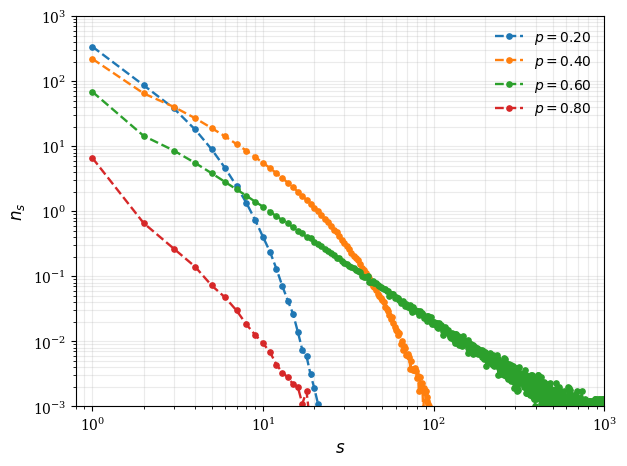

In [16]:
#| label: cell:csd
fig_csd